In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the TSV file with no header
file_path = "merged_orcacle.tsv"
data = pd.read_csv(file_path, sep='\t', header=None, names=['query', 'loss', 'method'])

data = data.sort_values(by='loss', ascending=True)


data.head(1000)



,query,loss,method
129175,does cellular respiration require a mitochondria,1.270185,23
354712,are inhalants depressants or stimulants,1.278784,23
155648,which blood vessel of the pulmonary circuit wi...,1.282125,23
153550,bladder infection causes,1.283336,23
173126,define pupae,1.288618,23
...,...,...,...
350816,what's a ftp server?,1.452428,23
238198,how to make homemade ice coffee,1.452528,23
463935,hawaiitax on line,1.452571,14
284129,how long to cook a 5 pound duck,1.452628,23


                                               query      loss  method  group
71357                  ca.rogers.yahoo.com home page  1.880023      23  SYNTH
187935                when is dental assistant week?  1.882668      23  MARCO
57417             large group halloween costume idea  1.884530      23  SYNTH
98777                            wood pellet machine  1.884632      23  SYNTH
70419                   december uk weather forecast  1.884845      23  SYNTH
...                                              ...       ...     ...    ...
124280                          define bootstrapping  1.895098      23  MARCO
182368                           maximum ss benefits  1.895104      23  MARCO
12207   outboard mechanical and electrics gold coast  1.895107      23  SYNTH
115058             convert table from yards to miles  1.895111      23  MARCO
112659                          what is escolar fish  1.895116      23  MARCO

[1000 rows x 4 columns]


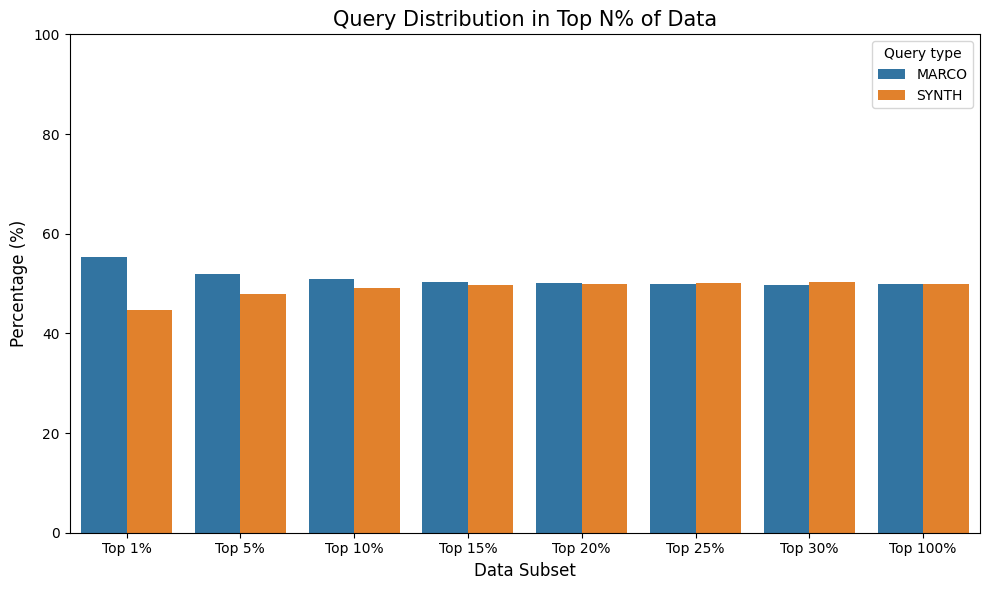

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the TSV file with no header
file_path = "merged.tsv"
data = pd.read_csv(file_path, sep='\t', header=None, names=['query', 'loss', 'method', 'group'])
data = data.sort_values(by='loss', ascending=True)

print(data.head(1000))

def compute_top_percentage(data, methods, percentage):
    total_rows = len(data)
    top_n_count = int((percentage / 100) * total_rows)
    top_n_data = data.head(top_n_count)
    
    percentages = {}
    for method in methods:
        count = (top_n_data['group'] == method).sum()
        percentages[method] = (count / top_n_count) * 100 if top_n_count > 0 else 0
    return percentages

# Define methods
methods = ["MARCO", "SYNTH"]
top_ns = [1, 5, 10, 15, 20, 25, 30, 100]

# Prepare data for plotting
plot_data = []
for percentage in top_ns:
    percentages = compute_top_percentage(data, methods, percentage)
    for method, percent in percentages.items():
        plot_data.append({
            'Top N%': f'Top {percentage}%', 
            'Method': method, 
            'Percentage': percent
        })

# Convert to DataFrame
plot_df = pd.DataFrame(plot_data)

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Top N%', y='Percentage', hue='Method', data=plot_df)
plt.title('Query Distribution in Top N% of Data', fontsize=15)
plt.xlabel('Data Subset', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(title='Query type')
plt.tight_layout()
plt.show()